In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [2]:
# data visualisation
df = pd.read_csv("C:/Users/Honey/Downloads/D__INETPUB_VHOSTS_ajointus.com_httpdocs_Uploads_Cab_AI_Centre_Surge_data.csv")

print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Price range: ${df['price'].min()} – ${df['price'].max()}")
print(f"Cab types: {df['cab_type'].unique().tolist()}  ← only one, will drop")
print(f"Cab names: {df['name'].unique().tolist()}")
print(f"Destinations: {df['destination'].nunique()} unique")
print(f"Sources: {df['source'].nunique()} unique")

Dataset shape: (66367, 57)
Missing values: 0
Price range: $4.5 – $76.0
Cab types: ['Cab']  ← only one, will drop
Cab names: ['CabXL', 'CabX', 'CabPool']
Destinations: 12 unique
Sources: 12 unique


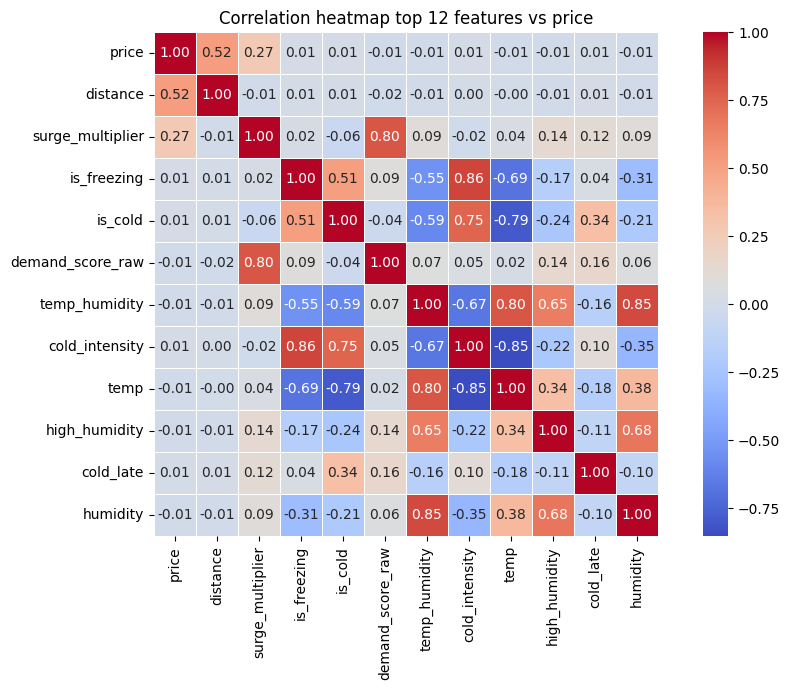

In [3]:
# heatmap

top_corr_cols = df.select_dtypes(include=np.number).corr()['price'].abs()\
                  .sort_values(ascending=False).head(12).index.tolist()
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[top_corr_cols].corr(),
    annot=True, fmt=".2f", cmap='coolwarm',
    linewidths=0.5, square=True
)
plt.title("Correlation heatmap top 12 features vs price")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# handle missing values
df = df.dropna()

In [5]:
# features and target
X = df.drop(columns=["surge_multiplier", "cab_type"])
y = df["surge_multiplier"]

categorical_cols = ["name", "destination", "source"]
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

In [6]:
# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ]
)

In [7]:
# split train test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
# perform multi models and hyperparameters
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 10, 20],
            "model__min_samples_split": [2, 5]
        }
    },
    
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [3, 5]
        }
    },
    
    "XGBoost": {
        "model": XGBRegressor(random_state=42, verbosity=0),
        "params": {
            "model__n_estimators": [200, 300],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [4, 6],
            "model__subsample": [0.8, 1.0]
        }
    }
}

In [9]:
# train model, tune and evaluate
results = []

for name, config in models.items():
    print(f"\n{name}")
    
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", config["model"])
    ])
    
    if config["params"]:
        search = RandomizedSearchCV(
            pipeline,
            config["params"],
            cv=5,
            scoring="r2",
            n_jobs=-1,
            n_iter=10,
            random_state=42
        )
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        print("Best Params:", search.best_params_)
    else:
        best_model = pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model.predict(X_test)
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="r2")
    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "CV_R2": cv_scores.mean()
    })
    
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print(f"CV R2: {cv_scores.mean():.4f}")



LinearRegression
MAE: 0.1153
RMSE: 0.1524
R2: 0.8755
CV R2: 0.8733

RandomForest
Best Params: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__max_depth': 10}
MAE: 0.0107
RMSE: 0.0418
R2: 0.9906
CV R2: 0.9899

GradientBoosting
Best Params: {'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.1}
MAE: 0.0107
RMSE: 0.0416
R2: 0.9907
CV R2: 0.9900

XGBoost
Best Params: {'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.05}
MAE: 0.0129
RMSE: 0.0448
R2: 0.9892
CV R2: 0.9887


In [10]:
# create result dataframe
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("\nFinal Model Comparison:\n", results_df)


Final Model Comparison:
               Model       MAE      RMSE        R2     CV_R2
2  GradientBoosting  0.010720  0.041593  0.990721  0.989994
1      RandomForest  0.010740  0.041837  0.990612  0.989865
3           XGBoost  0.012856  0.044810  0.989230  0.988700
0  LinearRegression  0.115332  0.152367  0.875484  0.873312


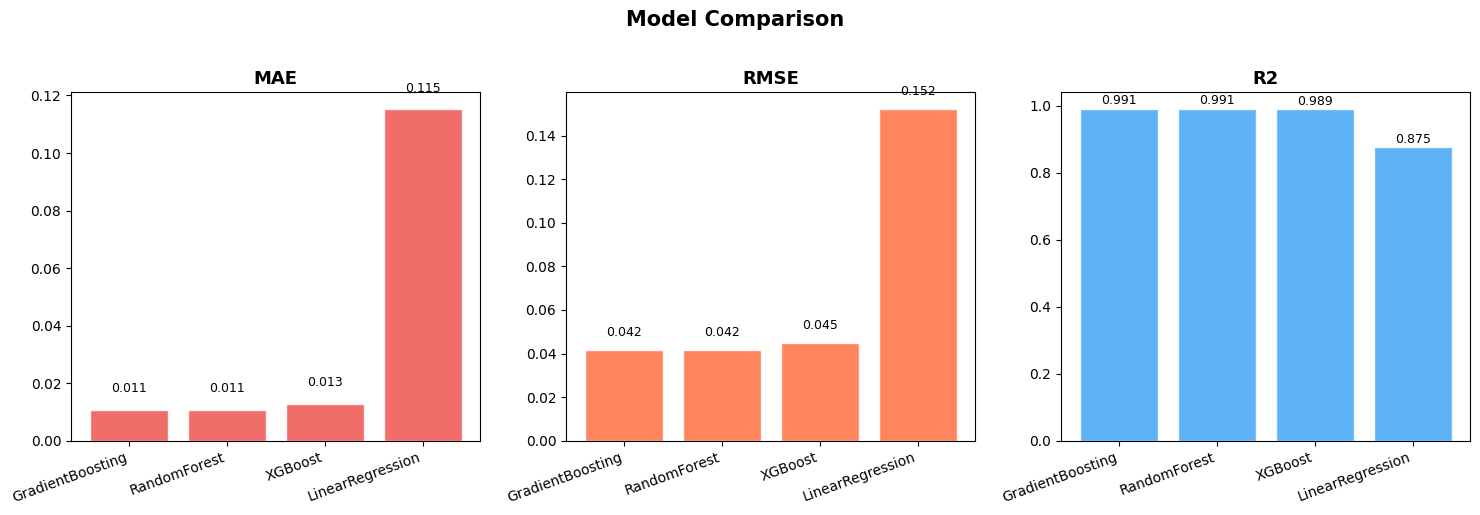

In [11]:
# visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ["MAE", "RMSE", "R2"]
colors    = ["#EF5350", "#FF7043", "#42A5F5"]
 
for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df["Model"], results_df[metric], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticklabels(results_df["Model"], rotation=20, ha='right')
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha='center', va='bottom', fontsize=9
        )
 
plt.suptitle("Model Comparison", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


Best Model: GradientBoosting


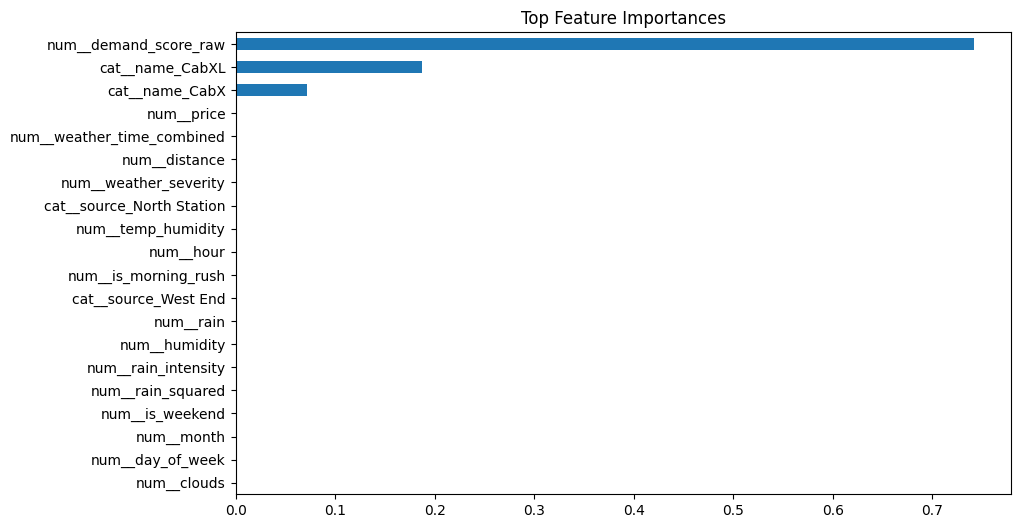

In [12]:
# feature importance
best_model_name = results_df.iloc[0]["Model"]
print(f"\nBest Model: {best_model_name}")

# Retrain best model to extract importance
best_config = models[best_model_name]

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_config["model"])
])

pipeline.fit(X_train, y_train)

model = pipeline.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
    
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)[:20]
    
    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind="barh")
    plt.title("Top Feature Importances")
    plt.gca().invert_yaxis()
    plt.show()

In [13]:
# import joblib
# joblib.dump(pipeline, "Best_model.pkl")
# print("Model Download Successfully!")